In [1]:
import pandas as pd
import math
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch
import torch.nn as nn

df = yf.download('^BSESN', 
                        start='2010-01-01', 
                        end='2021-06-12', 
                        progress=True,
    )
#print(df.head())
df['Daily_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['3_D']=df['Close'] - df['Close'].shift(3)
df['5_D']=df['Close'] - df['Close'].shift(5)
df['5D_Mean'] = df['Close'].rolling(window=5).mean()
df['Momentum'] = df['Close'] - df['Close'].shift(3)
df['3D_log_return'] = np.log(df['Close'].shift(-3) / df['Close'])
# after df.dropna() but before you define features/X
df.columns = [col[0] for col in df.columns.to_flat_index()]
col = [c[0] for c in df.columns.to_flat_index()]
df['Target'] = (df['3D_log_return'] > 0).astype(int)
df.dropna(inplace=True)
#plt.plot(df['3D_log_return'],df['Open'],label='Open')

print(col)

C:\Users\umava\AppData\Local\Temp\ipykernel_5024\277486714.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^BSESN',
[*********************100%***********************]  1 of 1 completed

['C', 'H', 'L', 'O', 'V', 'D', '3', '5', '5', 'M', '3']


In [2]:
# 1) Drop future info and target
features = df.drop(columns=['3D_log_return', 'Target'])

# 2) Build X and y
X = features
y = df['Target']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 2: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Step 2: Predict on test set
y_pred = log_reg.predict(X_test)

# Step 3: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5472370766488414
Confusion Matrix:
 [[  2 250]
 [  4 305]]
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.01      0.02       252
           1       0.55      0.99      0.71       309

    accuracy                           0.55       561
   macro avg       0.44      0.50      0.36       561
weighted avg       0.45      0.55      0.40       561



        Feature  Importance
7           5_D    0.128393
5  Daily_return    0.125686
4        Volume    0.109123
6           3_D    0.096196
9      Momentum    0.096033
8       5D_Mean    0.093585
0         Close    0.088497
3          Open    0.088418
2           Low    0.087816
1          High    0.086254


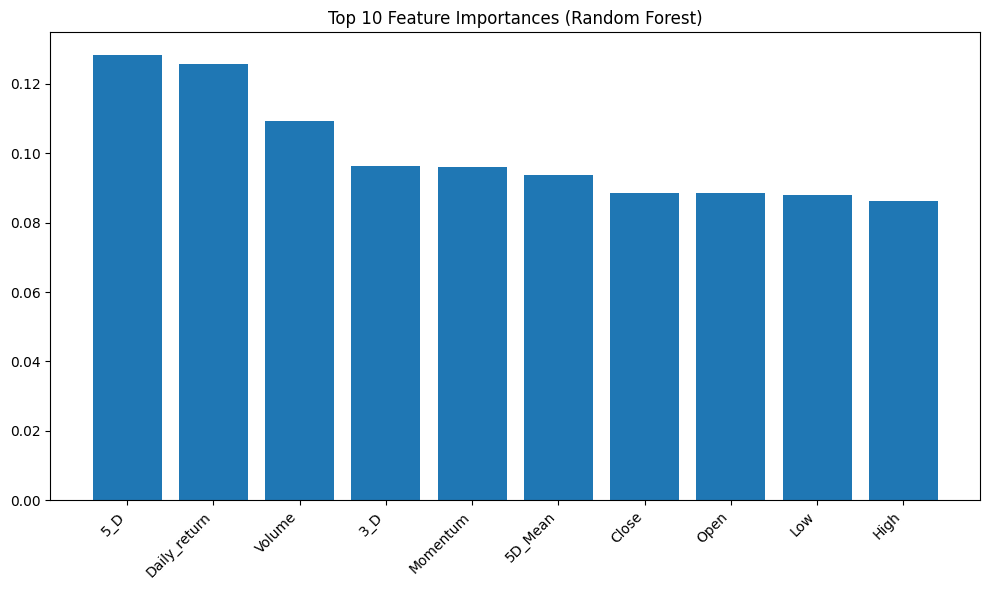

In [4]:
# Assuming X is still a DataFrame when you scaled it:
feature_names = X.columns
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Get importances
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(importance_df.head(10))
# Plot top 10
top = importance_df.head(10)
plt.figure(figsize=(10,6))
plt.bar(top['Feature'], top['Importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


In [5]:
# Evaluate predictions
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.5757575757575758
Confusion Matrix:
 [[120 132]
 [106 203]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.48      0.50       252
           1       0.61      0.66      0.63       309

    accuracy                           0.58       561
   macro avg       0.57      0.57      0.57       561
weighted avg       0.57      0.58      0.57       561



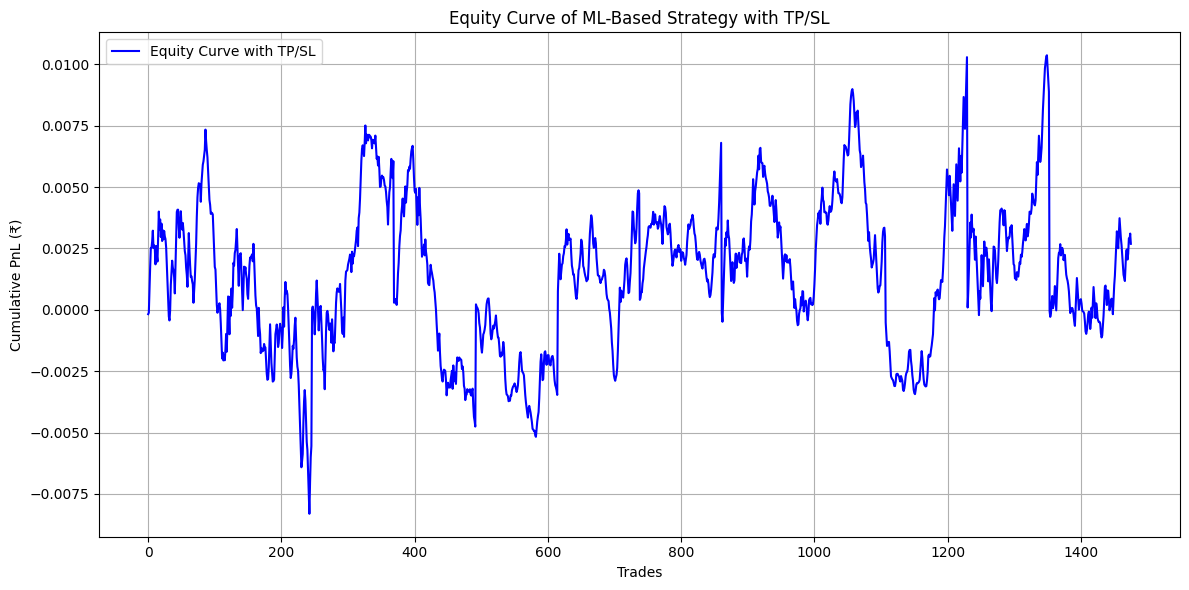

Cumulative Return (₹): 0.002689
Sharpe Ratio: 0.045577
Max Drawdown (₹): 0.015649


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
IS_years = 5
OOS_years = 0.5
step_years = 0.5
position_cap = 1000
TP = 0.01   # Take-profit threshold (3%)
SL = 0.02   # Stop-loss threshold (2%)

feat = list(features.columns)
IS_days = int(IS_years * 252)
OOS_days = int(OOS_years * 252)
step_days = int(step_years * 252)

equity_curves = []

for start in range(0, len(df) - IS_days - OOS_days - 3, step_days):
    train = df.iloc[start : start + IS_days].copy()
    test = df.iloc[start + IS_days : start + IS_days + OOS_days].copy()

    rf.fit(train[feat], train['Target'])
    test['signal'] = rf.predict(test[feat])

    test['entry_price'] = test['Open'].shift(-1)
    test['qty'] = position_cap / test['entry_price']
    
    trade_returns = []

    for i in range(len(test) - 3):
        row = test.iloc[i]
        signal = row['signal']
        entry_price = row['entry_price']
        
        if pd.isna(entry_price): continue
        
        # Get next 3 rows for exit check
        horizon = test.iloc[i+1:i+4]
        tp_hit = False
        sl_hit = False

        for j, day in enumerate(horizon.itertuples()):
            high = day.High
            low = day.Low

            if signal == 1:  # Long
                if high >= entry_price * (1 + TP):
                    exit_price = entry_price * (1 + TP)
                    tp_hit = True
                    break
                elif low <= entry_price * (1 - SL):
                    exit_price = entry_price * (1 - SL)
                    sl_hit = True
                    break
            else:  # Short
                if low <= entry_price * (1 - TP):
                    exit_price = entry_price * (1 - TP)
                    tp_hit = True
                    break
                elif high >= entry_price * (1 + SL):
                    exit_price = entry_price * (1 + SL)
                    sl_hit = True
                    break

        if not tp_hit and not sl_hit:
            # Fallback: sell at close on 3rd day
            exit_price = test.iloc[i+3]['Close']

        # Return = log(exit/entry) * qty
        mult = 1 if signal == 1 else -1
        ret = np.log(exit_price / entry_price) * row['qty'] * mult
        trade_returns.append(ret)

    # Create equity curve
    tc = pd.DataFrame({'trade_return': trade_returns})
    tc['equity'] = tc['trade_return'].cumsum()
    equity_curves.append(tc['equity'])

# ---- Aggregate walk-forward curves ----
equity_all = pd.concat(equity_curves).reset_index(drop=True)

# ---- Plot ----
plt.figure(figsize=(12, 6))
plt.plot(equity_all, label='Equity Curve with TP/SL', color='blue')
plt.title('Equity Curve of ML-Based Strategy with TP/SL')
plt.xlabel('Trades')
plt.ylabel('Cumulative PnL (₹)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Metrics ----
cum_return = equity_all.iloc[-1]
daily_returns = equity_all.diff().dropna()
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
max_dd = (equity_all.cummax() - equity_all).max()

print(f"Cumulative Return (₹): {cum_return:.6f}")
print(f"Sharpe Ratio: {sharpe:.6f}")
print(f"Max Drawdown (₹): {max_dd:.6f}")
